# 10-Year 105,120 5-Minute Interval Direct HMM Transition Analysis & Dataset Generation

## Objectives
1. **Load 10-Year 5-Minute Rainfall Data (4-Gauge Average)**: Aggregate 5-minute spatial average rainfall records across all 4 rain gauges in Astlingen (2000–2009) into a 10-year 5-minute dataset (1,051,200 records).
2. **Construct 1-Year (105,120 5-Minute Interval) Climatological 1D Rainfall Profile**: Rather than extracting daily features, aggregate 5-minute intervals across all 10 years by annual interval position (365 days × 288 intervals/day = 105,120 slots) to compute the 10-year mean 5-minute rainfall profile. Apply a 14-day rolling window (4,032 5-minute steps) for climatological smoothing.
3. **Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Rainfall Profile**: Train a 4-state GaussianHMM directly on the standardized 105,120 3D climatological rainfall profile.
4. **Reorder & Characterize HMM States**: Sort state indices (0 to 3) by mean rainfall intensity (State 0: Dry/Low Activity, State 1: Light/Moderate Rain, State 2: Heavy/Convective Rain, State 3: Peak/Intense Storms).
5. **Observe & Visualize 105,120-Interval Transition Matrix**: Extract the 4x4 state transition matrix, compute transition dynamics, and render a high-quality heatmap visualization.
6. **Visualize 105,120-Interval Climatological Regimes**: Plot the annual 105,120 5-minute rainfall profile colored by hidden state transitions across the 365-day year.
7. **Broadcast 105,120 HMM State Sequence to Full 5-Minute Dataset**: Map the 105,120 5-minute HMM state sequence back to each 5-minute record in the 10-year dataset (1,051,200 records).
8. **Export New Labeled Dataset**: Save the dataset containing `date`, `time`, `rainfall_intensity`, `day_of_year`, and `hmm_state` to `../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_fit_hmm.csv`.
9. **Visualize Sample 5-Minute Time Series with Broadcasted HMM States**: Render a sample 14-day window of 5-minute rainfall intensity overlaid with background shading for the predicted HMM state regimes.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Step 1: Load 10-Year 5-Minute Data & Compute 4-Gauge Average
We load all 4 rain gauge datasets (Astlingen Erft 1–4) for 2000–2009, compute the spatial average 5-minute rainfall intensity, and set up annual interval indexing (0 to 105,119).

In [2]:
# Load all 4 raw 5-minute rainfall gauge datasets
file_paths = sorted(glob.glob('../data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))
if not file_paths:
    file_paths = sorted(glob.glob('data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))

print(f"Loading {len(file_paths)} rain gauge datasets:")
for p in file_paths:
    print(f" - {p}")

gauge_dfs = []
for path in file_paths:
    g_df = pd.read_csv(path)
    g_df['datetime'] = pd.to_datetime(g_df['date'] + ' ' + g_df['time'], format='%m/%d/%Y %H:%M:%S')
    g_df.set_index('datetime', inplace=True)
    gauge_dfs.append(g_df['rainfall_intensity'])

# Combine and compute 4-gauge average 5-minute rainfall intensity
df_5min_full = pd.concat(gauge_dfs, axis=1).mean(axis=1).to_frame(name='rainfall_intensity').reset_index()

# Add year, day_of_year, interval_of_day
df_5min_full['year'] = df_5min_full['datetime'].dt.year
df_5min_full['day_of_year'] = df_5min_full['datetime'].dt.dayofyear
df_5min_full['interval_of_day'] = (df_5min_full['datetime'].dt.hour * 12 + df_5min_full['datetime'].dt.minute // 5)

# Calculate annual 5-minute interval index (0 to 105,119)
day_capped = df_5min_full['day_of_year'].clip(upper=365)
df_5min_full['annual_interval_idx'] = (day_capped - 1) * 288 + df_5min_full['interval_of_day']

print(f"Full 10-Year 5-Minute Dataset Shape: {df_5min_full.shape}")
df_5min_full.head()

Loading 4 rain gauge datasets:
 - ../data/rainfall/astlingen/1Astlingen_Erft1.csv
 - ../data/rainfall/astlingen/2Astlingen_Erft2.csv
 - ../data/rainfall/astlingen/3Astlingen_Erft3.csv
 - ../data/rainfall/astlingen/4Astlingen_Erft4.csv
Full 10-Year 5-Minute Dataset Shape: (1051200, 6)


,datetime,rainfall_intensity,year,day_of_year,interval_of_day,annual_interval_idx
0,2000-01-01 00:00:00,0.005,2000,1,0,0
1,2000-01-01 00:05:00,0.000,2000,1,1,1
2,2000-01-01 00:10:00,0.000,2000,1,2,2
3,2000-01-01 00:15:00,0.000,2000,1,3,3
4,2000-01-01 00:20:00,0.000,2000,1,4,4


## Step 2: Construct 1-Year (105,120 5-Minute Interval) Climatological 1D Rainfall Profile
We average across 10 years by `annual_interval_idx` (0 to 105,119) to form a 1D rainfall profile of 105,120 rows, then apply a 14-day rolling mean (4,032 5-minute steps) to smooth high-frequency noise into continuous seasonal signals.

In [3]:
# Filter out leap-year day 366 for consistent 365-day annual alignment (365 * 288 = 105,120 intervals)
df_365 = df_5min_full[df_5min_full['day_of_year'] <= 365].copy()

# ── Step A: Daily aggregation (same 3 features as the 365-fit HMM) ──
df_365_indexed = df_365.set_index('datetime')

daily_365 = pd.DataFrame({
    'total_rain':     df_365_indexed['rainfall_intensity'].resample('D').sum(),
    'max_intensity':  df_365_indexed['rainfall_intensity'].resample('D').max(),
    'rain_fraction':  (df_365_indexed['rainfall_intensity'] > 0).astype(int).resample('D').mean(),
}).reset_index()

daily_365['day_of_year'] = daily_365['datetime'].dt.dayofyear
daily_365 = daily_365[daily_365['day_of_year'] <= 365]  # drop leap day

# ── Step B: Average across 10 years by day_of_year → 365-day climatological means ──
clim_daily = daily_365.groupby('day_of_year')[['total_rain', 'max_intensity', 'rain_fraction']].mean()

# Apply 14-day rolling window (same as 365-fit)
clim_daily_smooth = clim_daily.rolling(window=14, min_periods=1, center=True).mean()

# ── Step C: Broadcast these 3 daily features to every 5-min interval ──
# Each 5-min interval gets its day-of-year's daily features
# This gives 105,120 rows × 3 features, exactly matching the 105120 interval index
clim_105120 = df_365.groupby('annual_interval_idx').agg(
    rainfall_intensity=('rainfall_intensity', 'mean'),
    day_of_year=('day_of_year', 'first'),
).reset_index().set_index('annual_interval_idx')

# Merge daily features onto the interval-level frame
clim_105120 = clim_105120.join(
    clim_daily_smooth.rename(columns={
        'total_rain': 'total_rain',
        'max_intensity': 'max_intensity',
        'rain_fraction': 'rain_fraction',
    }),
    on='day_of_year',
)

# Also keep smoothed intensity for plotting/backward-compat
clim_105120['rainfall_intensity_smooth'] = clim_105120['rainfall_intensity'].rolling(
    window=4032, min_periods=1, center=True).mean()

print(f"105,120-interval climatological profile with 3 daily features: {clim_105120.shape}")
print(clim_105120[['total_rain', 'max_intensity', 'rain_fraction']].head())


105,120-interval climatological profile with 3 daily features: (105120, 6)
                     total_rain  max_intensity  rain_fraction
annual_interval_idx                                          
0                      2.362643       0.160643       0.119097
1                      2.362643       0.160643       0.119097
2                      2.362643       0.160643       0.119097
3                      2.362643       0.160643       0.119097
4                      2.362643       0.160643       0.119097


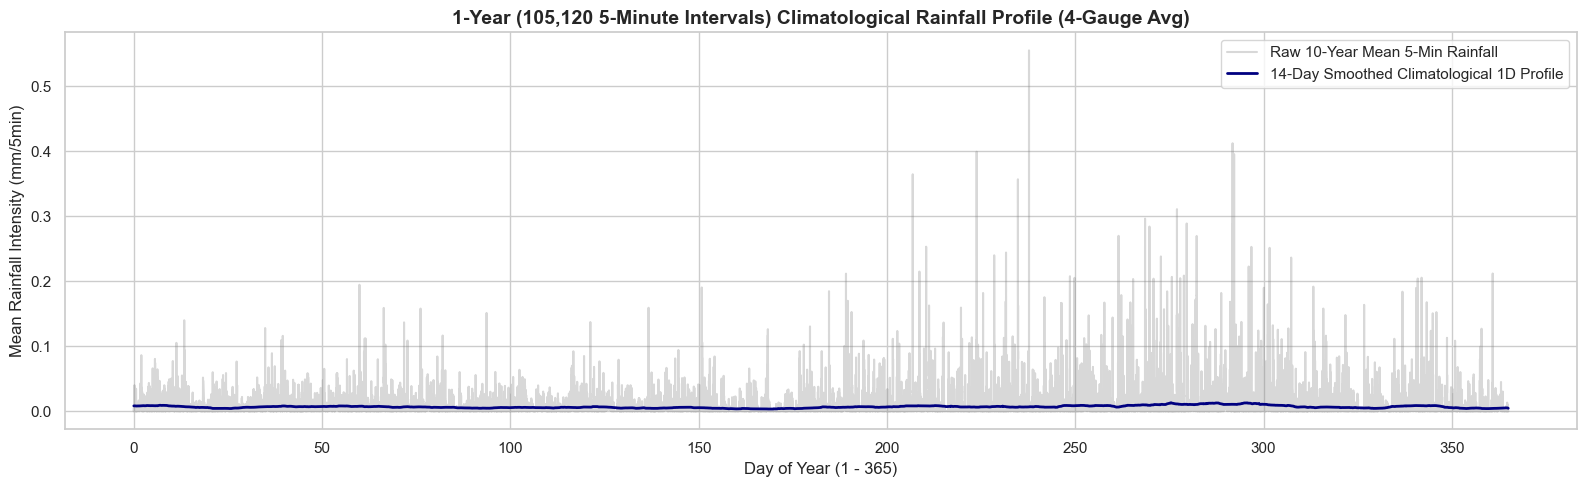

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0
ax.plot(days, clim_105120['rainfall_intensity'], alpha=0.3, color='gray', label='Raw 10-Year Mean 5-Min Rainfall')
ax.plot(days, clim_105120['rainfall_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Climatological 1D Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Rainfall Profile (4-Gauge Avg)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Step 3: Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Rainfall Profile
We standardize the 105,120 1D smoothed climatological rainfall intensity profile and train a 4-state GaussianHMM directly on the 105,120 interval sequence.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clim_105120[['total_rain', 'max_intensity', 'rain_fraction']])

n_states = 4
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=200, random_state=42)
hmm_model.fit(X_scaled)

raw_states = hmm_model.predict(X_scaled)
clim_105120['raw_state'] = raw_states

# Reorder states by mean total_rain (same criterion as 365-fit)
state_means = clim_105120.groupby('raw_state')['total_rain'].mean().sort_values()
state_map = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}
clim_105120['hmm_state'] = clim_105120['raw_state'].map(state_map)

# Also reorder the transition matrix (same as 365-fit)
transmat_raw = hmm_model.transmat_
transmat_ordered = np.zeros_like(transmat_raw)
for old_i, new_i in state_map.items():
    for old_j, new_j in state_map.items():
        transmat_ordered[new_i, new_j] = transmat_raw[old_i, old_j]

print("HMM Fitting Complete!")
print(f"Re-ordered State Means (Total Daily Rain mm):\n{clim_105120.groupby('hmm_state')['total_rain'].mean()}")

HMM Fitting Complete!
Re-ordered State Means (Total Daily Rain mm):
hmm_state
0    1.581092
1    1.789503
2    2.415040
3    2.728777
Name: total_rain, dtype: float64


## Step 4: Observe & Visualize Transition Matrix
We extract the 4x4 state transition matrix from the 105,120 predicted HMM state sequence and render a high-quality heatmap visualization.

In [6]:
state_names = [
    f'State 0 (Dry / Low Activity)',
    f'State 1 (Moderate / Light Rain)',
    f'State 2 (Heavy / Convective)',
    f'State 3 (Peak / Intense Storms)'
]

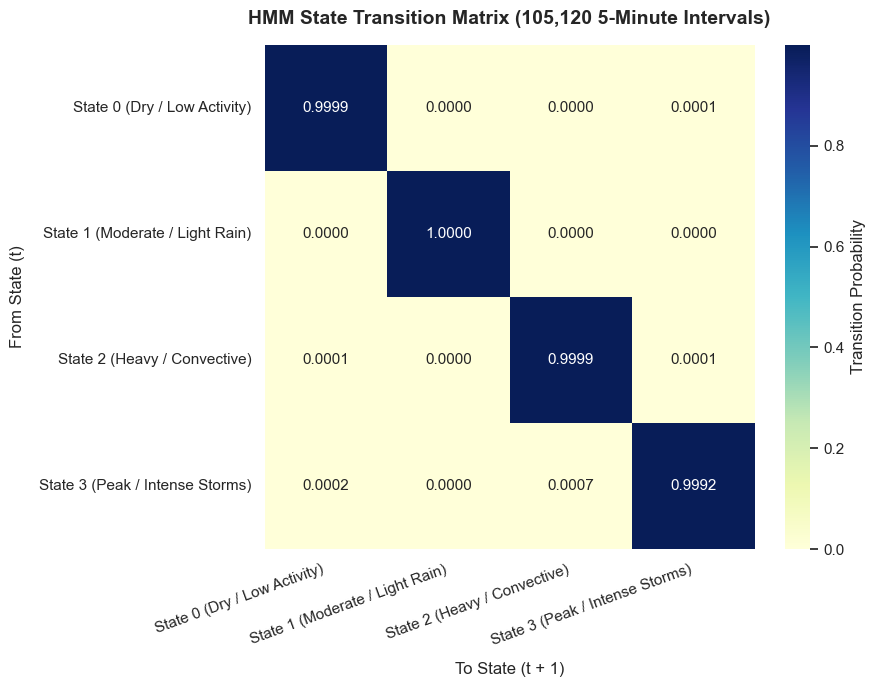

,State 0 (Dry / Low Activity),State 1 (Moderate / Light Rain),State 2 (Heavy / Convective),State 3 (Peak / Intense Storms)
State 0 (Dry / Low Activity),0.999898,0.000000,0.000000,0.000102
State 1 (Moderate / Light Rain),0.000023,0.999977,0.000000,0.000000
State 2 (Heavy / Convective),0.000075,0.000000,0.999851,0.000075
State 3 (Peak / Intense Storms),0.000165,0.000000,0.000661,0.999173


In [7]:
# Compute 4x4 empirical transition matrix across 105,120 intervals
trans_matrix = np.zeros((n_states, n_states))
for t in range(len(clim_105120) - 1):
    i = clim_105120['hmm_state'].iloc[t]
    j = clim_105120['hmm_state'].iloc[t+1]
    trans_matrix[i, j] += 1

# Normalize transition matrix rows to probabilities
trans_matrix_prob = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)

# Plot Transition Matrix Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(trans_matrix_prob, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=state_names, yticklabels=state_names,
            cbar_kws={'label': 'Transition Probability'})
plt.title("HMM State Transition Matrix (105,120 5-Minute Intervals)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("To State (t + 1)", fontsize=12, labelpad=10)
plt.ylabel("From State (t)", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Transition Probabilities DataFrame
trans_df = pd.DataFrame(trans_matrix_prob, index=state_names, columns=state_names)
trans_df

## Step 5: Visualize 105,120-Interval Climatological Regimes & State Transitions
We plot the 105,120 5-minute annual rainfall profile colored by hidden state transitions across the 365 days of the year.

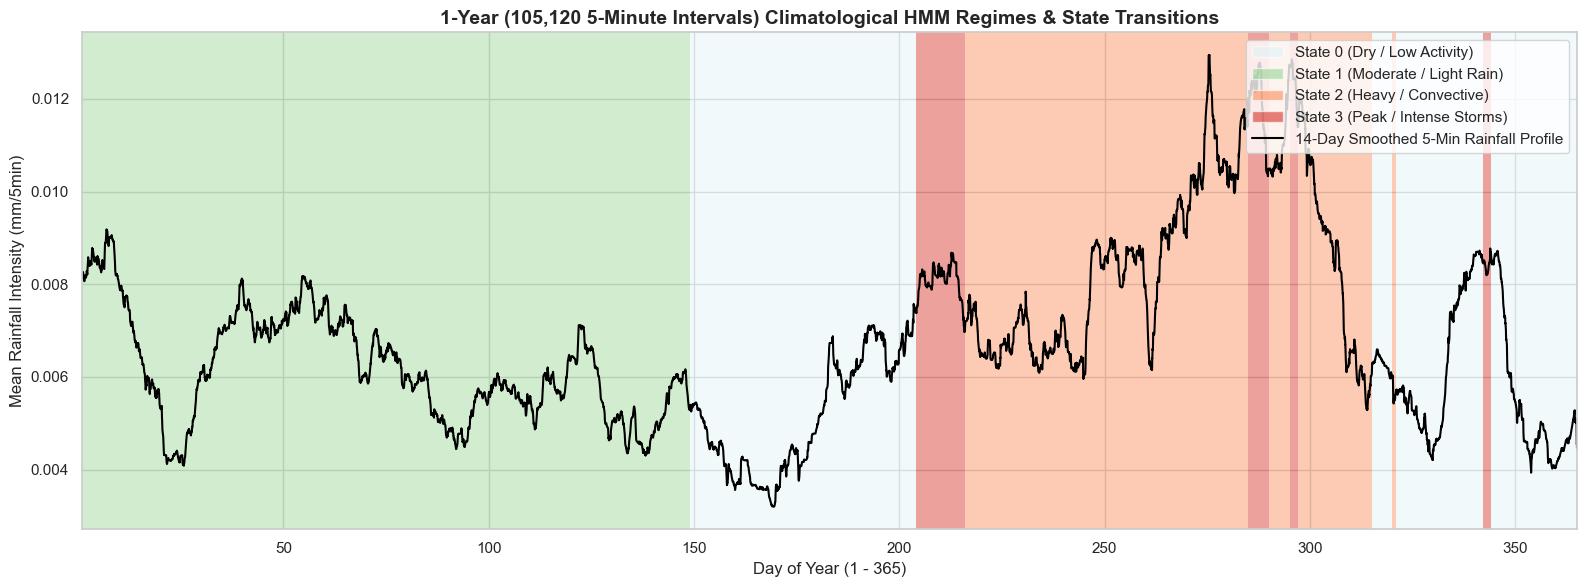

In [8]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, ax = plt.subplots(figsize=(16, 6))

days = clim_105120.index / 288.0

# Background shading for HMM states across 105,120 intervals
current_state = clim_105120['hmm_state'].iloc[0]
start_idx = 0

for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != current_state or i == len(clim_105120) - 1:
        ax.axvspan(days[start_idx], days[i], color=colors[current_state], alpha=0.45, linewidth=0)
        current_state = clim_105120['hmm_state'].iloc[i]
        start_idx = i

ax.plot(days, clim_105120['rainfall_intensity_smooth'], color='black', linewidth=1.5, label='14-Day Smoothed 5-Min Rainfall')

# Custom legend for HMM states
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.5, label='14-Day Smoothed 5-Min Rainfall Profile'))

ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological HMM Regimes & State Transitions', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlim(1, 365)

plt.tight_layout()
plt.show()

## Step 6: HMM Regime Characterization Summary
We aggregate statistics (mean intensity, interval count, and percentage of year) for each of the 4 discovered HMM states across the 105,120 intervals.

In [9]:
summary_df = clim_105120.groupby('hmm_state')[['total_rain', 'max_intensity', 'rain_fraction']].mean()
summary_df['Interval_Count'] = clim_105120.groupby('hmm_state').size()
summary_df['Pct_of_Year'] = (summary_df['Interval_Count'] / len(clim_105120) * 100).round(2)
summary_df.index = state_names
summary_df


,total_rain,max_intensity,rain_fraction,Interval_Count,Pct_of_Year
State 0 (Dry / Low Activity),1.581092,0.142643,0.073009,29375,27.94
State 1 (Moderate / Light Rain),1.789503,0.118024,0.114318,42912,40.82
State 2 (Heavy / Convective),2.415040,0.275430,0.072262,26784,25.48
State 3 (Peak / Intense Storms),2.728777,0.257778,0.088393,6049,5.75


## Step 7: Broadcast 105,120-Interval HMM State Sequence to Full 5-Minute Dataset
We map the 105,120 5-minute HMM state sequence (`hmm_state` 0–3) back to each 5-minute record in the 10-year dataset (1,051,200 records) based on `annual_interval_idx`.

In [10]:
# Create mapping from annual_interval_idx (0 to 105,119) to HMM state
interval_state_map = clim_105120['hmm_state'].to_dict()

# Broadcast 105,120 HMM state to full 5-minute dataset
df_5min_full['hmm_state'] = df_5min_full['annual_interval_idx'].map(interval_state_map).astype(int)

df_5min_full['date'] = df_5min_full['datetime'].dt.strftime('%d/%m/%Y')
df_5min_full['time'] = df_5min_full['datetime'].dt.strftime('%H:%M:%S')

print("Broadcasting HMM State Sequence Complete!")
print(f"5-Minute Labeled Dataset Shape: {df_5min_full.shape}")
print("\nDistribution of HMM States in 5-Minute Dataset:")
print(df_5min_full['hmm_state'].value_counts().sort_index())

# Save labeled 5-minute dataset with hmm_state column
output_dir = '../data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(output_dir, 'dataset_with_105120_fit_hmm.csv')
df_5min_full[['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].to_csv(output_csv, index=False)
print(f"Saved 5-minute dataset with 105,120-fitted HMM states to: {output_csv}")

df_5min_full[['datetime', 'date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].head(10)

Broadcasting HMM State Sequence Complete!
5-Minute Labeled Dataset Shape: (1051200, 9)

Distribution of HMM States in 5-Minute Dataset:
hmm_state
0    294614
1    428256
2    267840
3     60490
Name: count, dtype: int64
Saved 5-minute dataset with 105,120-fitted HMM states to: ../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_fit_hmm.csv


,datetime,date,time,rainfall_intensity,day_of_year,hmm_state
0,2000-01-01 00:00:00,01/01/2000,00:00:00,0.005,1,1
1,2000-01-01 00:05:00,01/01/2000,00:05:00,0.000,1,1
2,2000-01-01 00:10:00,01/01/2000,00:10:00,0.000,1,1
3,2000-01-01 00:15:00,01/01/2000,00:15:00,0.000,1,1
4,2000-01-01 00:20:00,01/01/2000,00:20:00,0.000,1,1
5,2000-01-01 00:25:00,01/01/2000,00:25:00,0.000,1,1
6,2000-01-01 00:30:00,01/01/2000,00:30:00,0.015,1,1
7,2000-01-01 00:35:00,01/01/2000,00:35:00,0.035,1,1
8,2000-01-01 00:40:00,01/01/2000,00:40:00,0.010,1,1
9,2000-01-01 00:45:00,01/01/2000,00:45:00,0.010,1,1


## Step 8: Visualize 5-Minute Time Series Sample with Broadcasted HMM States
We plot a sample 14-day window of 5-minute rainfall intensity overlaying the broadcasted HMM state background shading.

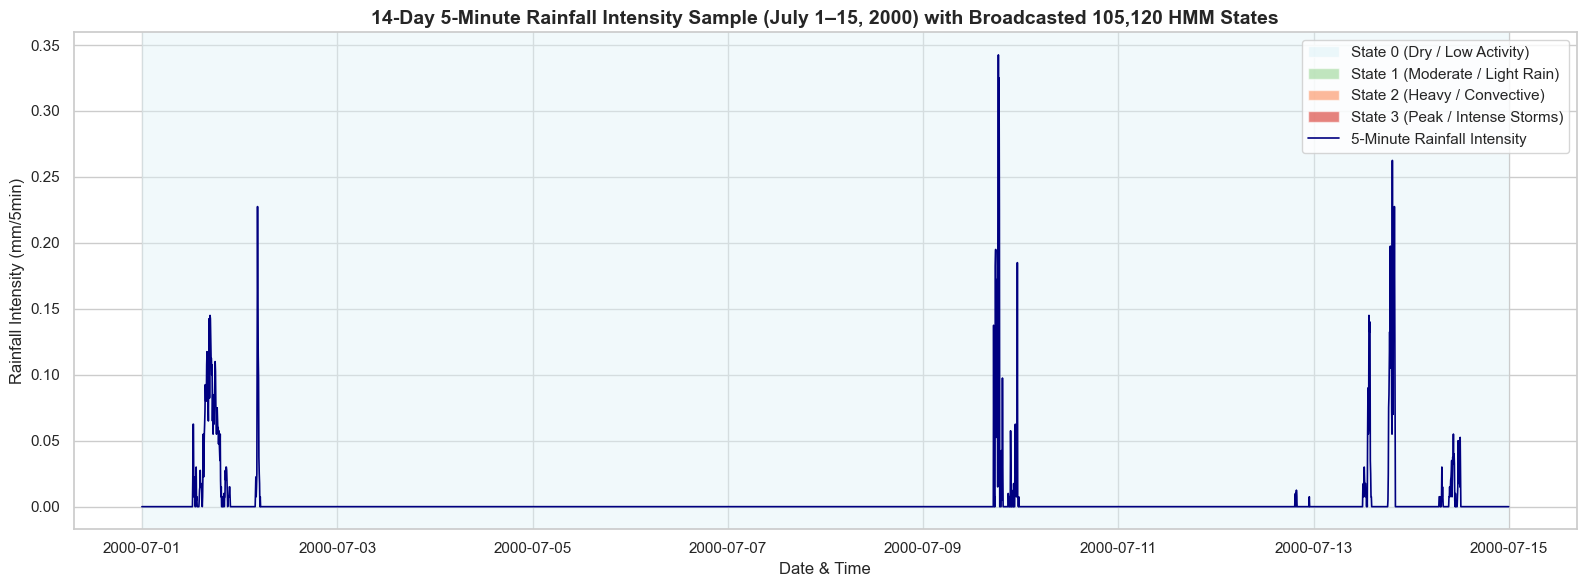

In [11]:
# Sample 14-day window (e.g. July 1 to July 15, 2000)
sample_df = df_5min_full[(df_5min_full['datetime'] >= '2000-07-01') & (df_5min_full['datetime'] < '2000-07-15')].copy()

fig, ax = plt.subplots(figsize=(16, 6))

times = sample_df['datetime']
rain = sample_df['rainfall_intensity']
states = sample_df['hmm_state'].values

# Background shading for broadcasted HMM states
current_st = states[0]
start_t = times.iloc[0]

for i in range(1, len(sample_df)):
    if states[i] != current_st or i == len(sample_df) - 1:
        ax.axvspan(start_t, times.iloc[i], color=colors[current_st], alpha=0.45, linewidth=0)
        current_st = states[i]
        start_t = times.iloc[i]

ax.plot(times, rain, color='navy', linewidth=1.2, label='5-Minute Rainfall Intensity')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Minute Rainfall Intensity'))

ax.set_title('14-Day 5-Minute Rainfall Intensity Sample (July 1–15, 2000) with Broadcasted 105,120 HMM States', fontsize=14, fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()